# Finetuning AlphaGenome's encoder on MPRA data

This notebook demos how to train an MLP regression head on a **frozen** AlphaGenome encoder for one LentiMPRA cell line (HepG2) from
[Agarwal et al. 2025](https://www.nature.com/articles/s41586-024-08430-9).

**Why encoder-only?**
MPRA constructs are short (~200–300 bp). The CNN encoder alone handles arbitrary short sequences and produces
contextual 1536-dimensional embeddings at 128 bp resolution. This approach leverages the rich sequence representations learned by large-scale generalist models while adapting them to specific regulatory tasks through task-specific prediction heads.

**Steps:**
1. Install dependencies
2. Download HepG2 LentiMPRA data
3. Define dataset, head, and training utilities
4. Configure hyperparameters
5. Load pretrained AlphaGenome backbone and freeze it
6. Create `MPRAHead` (LayerNorm → flatten → MLP → scalar output)
7. Build datasets and DataLoaders
8. Train (encoder-only forward, only head params updated)
9. Plot loss / Pearson curves and evaluate on test set

## 1. Install dependencies

In [1]:
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available(): print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA H100 80GB HBM3


## 2. Download HepG2 LentiMPRA data

Training data (HepG2 LentiMPRA) is downloaded from
[human_legnet](https://github.com/autosome-ru/human_legnet) (`datasets/original/HepG2.tsv`).
The TSV contains one row per unique MPRA insert with columns:
- `seq`: DNA sequence of the regulatory element
- `fold`: cross-validation fold (1–10)
- `rev`: strand (0 = forward; we keep forward only)
- `mean_value`: mean log-scale activity score across replicates

In [2]:
import os
import urllib.request
import pandas as pd

DATA_DIR = "./data/legnet_lentimpra"
os.makedirs(DATA_DIR, exist_ok=True)

HEPG2_URL = "https://raw.githubusercontent.com/autosome-ru/human_legnet/main/datasets/original/HepG2.tsv"
hepg2_path = os.path.join(DATA_DIR, "HepG2.tsv")
urllib.request.urlretrieve(HEPG2_URL, hepg2_path)
print(f"Downloaded to {hepg2_path}")

# Preview the data
df_all = pd.read_csv(hepg2_path, sep="\t")
df_fwd = df_all[df_all["rev"] == 0]
train_df = df_fwd[df_fwd["fold"].isin([2,3,4,5,6,7,8,9])]
print(f"Total forward-strand samples : {len(df_fwd):,}")
print(f"Training samples (folds 2-9)  : {len(train_df):,}")
df_fwd.head()

Downloaded to ./data/legnet_lentimpra/HepG2.tsv
Total forward-strand samples : 122,926
Training samples (folds 2-9)  : 98,336


,seq_id,seq,mean_value,fold,rev
0,DNasePeakNoPromoter1,AGGACCGGATCAACTCCTAACCCTAACCCTAACCCTAACCCTAACC...,-0.675,2,0
1,DNasePeakNoPromoter1_Reversed:,AGGACCGGATCAACTCGTTCTCCTCAGCACAGACCCGGAGAGCACC...,-0.274,2,0
2,DNasePeakNoPromoter10,AGGACCGGATCAACTTGTTTCTTAGGAAAGGCGGCCAACCCAGGGT...,0.908,10,0
3,DNasePeakNoPromoter10_Reversed:,AGGACCGGATCAACTGGTTAGAGCTCAAAGGTCACTCCGATGACAC...,0.276,10,0
4,DNasePeakNoPromoter100,AGGACCGGATCAACTATTACTCACACAAGACACACATTGTCTGCCG...,1.295,9,0


## 3. Custom classes

The cells below define custom dataset and head classes which we use to define our MPRA model:
- **`LentiMPRADataset`** — PyTorch `Dataset` that assembles MPRA constructs
  (seq + promoter + barcode), one-hot encodes them, and optionally applies
  reverse-complement and random-shift augmentations.
- **`MPRAHead`** — `nn.Module` MLP regression head that takes raw CNN encoder
  output `(B, n_pos, 1536)` and returns scalar activity predictions `(B,)`.
- **`train_epoch`** and **`evaluate`** — lightweight training/evaluation loops
  using MSE loss and Pearson r.

In [3]:
from __future__ import annotations

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from contextlib import nullcontext
from torch import Tensor
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

from alphagenome_pytorch.extensions.finetuning.utils import sequence_to_onehot
from alphagenome_pytorch.metrics import pearson_r


class LentiMPRADataset(Dataset):
    """PyTorch Dataset for LentiMPRA data (Agarwal et al., 2025).

    Assembles the full construct (seq + promoter + barcode), one-hot encodes it,
    pads or trims to ``sequence_length``, and optionally applies augmentations.

    Returns (seq_onehot, target) tuples where:
        seq_onehot : float32 tensor of shape (sequence_length, 4)
        target     : float32 scalar (log-scale MPRA activity)
    """

    PROMOTER_SEQ = "TCCATTATATACCCTCTAGTGTCGGTTCACGCAATG"  # 36 bp
    RAND_BARCODE = "AGAGACTGAGGCCAC"                       # 15 bp

    FOLD_SPLITS: dict[str, list[int]] = {
        "train": [2, 3, 4, 5, 6, 7, 8, 9],
        "val":   [1],
        "test":  [10],
    }

    def __init__(
        self,
        data_dir: str,
        cell_type: str = "HepG2",
        split: str = "train",
        sequence_length: int = 256,
        reverse_complement: bool = False,
        rc_prob: float = 0.5,
        random_shift: bool = False,
        shift_prob: float = 0.5,
        max_shift: int = 15,
        subset_frac: float = 1.0,
        seed: int = 42,
    ) -> None:
        assert split in ("train", "val", "test"), f"Unknown split: {split!r}"
        assert cell_type in ("HepG2", "K562", "WTC11"), f"Unknown cell_type: {cell_type!r}"

        self.sequence_length = sequence_length
        self.reverse_complement = reverse_complement
        self.rc_prob = rc_prob
        self.random_shift = random_shift
        self.shift_prob = shift_prob
        self.max_shift = max_shift
        self._rng = np.random.default_rng(seed)

        # Load TSV and filter
        df = pd.read_csv(os.path.join(data_dir, f"{cell_type}.tsv"), sep="\t")
        df = df[df["rev"] == 0]  # forward strand only
        df = df[df["fold"].isin(self.FOLD_SPLITS[split])].reset_index(drop=True)

        if subset_frac < 1.0:
            df = df.sample(frac=subset_frac, random_state=seed).reset_index(drop=True)

        self.sequences: list[str] = df["seq"].tolist()
        self.targets: np.ndarray = df["mean_value"].values.astype(np.float32)
        print(f"Loaded {len(self.sequences):,} {split} samples ({cell_type})")

    def _build_construct(self, seq: str) -> str:
        return seq + self.PROMOTER_SEQ + self.RAND_BARCODE

    def _pad_or_trim(self, onehot: np.ndarray) -> np.ndarray:
        L = onehot.shape[0]
        if L < self.sequence_length:
            pad = np.zeros((self.sequence_length - L, 4), dtype=np.float32)
            return np.concatenate([onehot, pad], axis=0)
        return onehot[: self.sequence_length]

    def _apply_reverse_complement(self, onehot: np.ndarray) -> np.ndarray:
        """Reverse the sequence and swap A↔T, C↔G (columns 0↔3, 1↔2)."""
        return onehot[::-1, :][:, [3, 2, 1, 0]].copy()

    def __len__(self) -> int:
        return len(self.sequences)

    def __getitem__(self, idx: int) -> tuple[Tensor, Tensor]:
        construct = self._build_construct(self.sequences[idx])
        target = self.targets[idx]

        # One-hot encode (uint8 → float32)
        onehot = sequence_to_onehot(construct).astype(np.float32)

        # Optional: random shift augmentation
        if self.random_shift and self._rng.random() < self.shift_prob:
            shift = int(self._rng.integers(-self.max_shift, self.max_shift + 1))
            onehot = np.roll(onehot, shift, axis=0)

        # Pad / trim to fixed length
        onehot = self._pad_or_trim(onehot)

        # Optional reverse complement augmentation
        if self.reverse_complement and self._rng.random() < self.rc_prob:
            onehot = self._apply_reverse_complement(onehot)

        return torch.from_numpy(onehot), torch.tensor(target)

In [4]:
class MPRAHead(nn.Module):
    """MLP head for MPRA activity score regression from encoder-only features.

    Accepts raw CNN encoder output ``(B, n_positions, encoder_dim)`` and predicts
    a scalar activity score per sequence.

    Architecture::
        encoder_output (B, n_pos, 1536)
          → LayerNorm
          → flatten  (B, n_pos * 1536)
          → Linear(n_pos * 1536, hidden_size) + ReLU + Dropout
          → Linear(hidden_size, 1)
          → squeeze → (B,)
    """

    ENCODER_DIM: int = 1536  # AlphaGenome encoder output channels

    def __init__(
        self,
        n_positions: int,
        hidden_size: int = 1024,
        dropout: float = 0.1,
    ) -> None:
        super().__init__()
        flatten_dim = n_positions * self.ENCODER_DIM
        self.norm = nn.LayerNorm(self.ENCODER_DIM)
        self.fc1 = nn.Linear(flatten_dim, hidden_size)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_size, 1)

    def forward(self, encoder_output: Tensor) -> Tensor:
        """Forward pass.

        Args:
            encoder_output: Raw CNN encoder features, shape (B, n_positions, ENCODER_DIM).

        Returns:
            Predicted activity scores, shape (B,).
        """
        x = self.norm(encoder_output)          # (B, n_pos, ENCODER_DIM)
        x = x.flatten(1)                       # (B, n_pos * ENCODER_DIM)
        x = F.relu(self.fc1(x))                # (B, hidden_size)
        x = self.dropout(x)
        x = self.fc2(x)                        # (B, 1)
        return x.squeeze(-1)                   # (B,)

We also define utilities to train and evaluate the MPRA model.

In [5]:
def train_epoch(
    model: nn.Module,
    head: MPRAHead,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    use_amp: bool = True,
) -> tuple[float, float]:
    """Train MPRAHead for one epoch (backbone frozen, encoder-only forward).

    The backbone is always kept in eval mode (all its parameters are frozen).
    Only ``head`` parameters receive gradient updates.

    Returns:
        (avg_mse_loss, pearson_r) over the epoch.
    """
    model.eval() 
    head.train()

    amp_ctx = (
        torch.autocast(device_type="cuda", dtype=torch.bfloat16)
        if use_amp and device.type == "cuda"
        else nullcontext()
    )

    total_loss = 0.0
    all_preds: list[Tensor] = []
    all_targets: list[Tensor] = []

    pbar = tqdm(loader, desc=" train", leave=False)
    for sequences, targets in pbar:
        sequences = sequences.to(device)           # (B, L, 4)
        targets   = targets.to(device).float()     # (B,)
        organism_idx = torch.zeros(
            sequences.shape[0], dtype=torch.long, device=device
        )

        # Frozen encoder forward
        with torch.no_grad():
            with amp_ctx:
                enc_out = model(
                    sequences, organism_idx, encoder_only=True
                )["encoder_output"]                # (B, n_pos, 1536)
        enc_out = enc_out.detach()

        # Head forward + MSE loss
        with amp_ctx:
            preds = head(enc_out)                  # (B,)
            loss = F.mse_loss(preds.float(), targets.float())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        all_preds.append(preds.detach().float().cpu())
        all_targets.append(targets.float().cpu())
        pbar.set_postfix({"mse": f"{loss.item():.4f}"})

    preds_cat   = torch.cat(all_preds)
    targets_cat = torch.cat(all_targets)
    return total_loss / len(loader), pearson_r(preds_cat, targets_cat)


@torch.no_grad()
def evaluate(
    model: nn.Module,
    head: MPRAHead,
    loader: DataLoader,
    device: torch.device,
    use_amp: bool = True,
) -> tuple[float, float]:
    """Evaluate MPRAHead on a DataLoader.

    Returns:
        (avg_mse_loss, pearson_r).
    """
    model.eval()
    head.eval()

    amp_ctx = (
        torch.autocast(device_type="cuda", dtype=torch.bfloat16)
        if use_amp and device.type == "cuda"
        else nullcontext()
    )

    total_loss = 0.0
    all_preds: list[Tensor] = []
    all_targets: list[Tensor] = []

    for sequences, targets in loader:
        sequences = sequences.to(device)
        targets   = targets.to(device).float()
        organism_idx = torch.zeros(
            sequences.shape[0], dtype=torch.long, device=device
        )

        with amp_ctx:
            enc_out = model(
                sequences, organism_idx, encoder_only=True
            )["encoder_output"]                    # (B, n_pos, 1536)
            preds = head(enc_out)                  # (B,)
            loss = F.mse_loss(preds.float(), targets.float())
            
        total_loss += loss.item()
        all_preds.append(preds.float().cpu())
        all_targets.append(targets.float().cpu())

    preds_cat   = torch.cat(all_preds)
    targets_cat = torch.cat(all_targets)
    return total_loss / len(loader), pearson_r(preds_cat, targets_cat)

## 4. Configuration

Define the following key settings for training:
- `SEQUENCE_LENGTH = 256` — All constructs are padded/trimmed to 256 bp. This gives **2 encoder positions**
  which are flattened to 2 × 1536 = 3072 features fed into the MLP.
- `PRETRAINED_WEIGHTS` — Path to the converted AlphaGenome PyTorch checkpoint.
  Run `scripts/convert_weights.py` once to produce this file from the original JAX weights.

In [6]:
from pathlib import Path

PRETRAINED_WEIGHTS      = "finetune_files/weights/fold_0_weights.pth" 
DATA_DIR                = "./data/legnet_lentimpra"
CELL_TYPE               = "HepG2"
SEQUENCE_LENGTH         = 256
N_ENC_POSITIONS         = SEQUENCE_LENGTH // 128 
HIDDEN_SIZE             = 1024
DROPOUT                 = 0.1
SUBSET_FRAC             = 1.0
BATCH_SIZE              = 32
NUM_EPOCHS              = 10   
LEARNING_RATE           = 1e-3
WEIGHT_DECAY            = 0.0
EARLY_STOPPING_PATIENCE = 5
CHECKPOINT_DIR = Path("./checkpoints_mpra")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration:")
print(f"  PRETRAINED_WEIGHTS : {PRETRAINED_WEIGHTS}")
print(f"  CELL_TYPE          : {CELL_TYPE}")
print(f"  SEQUENCE_LENGTH    : {SEQUENCE_LENGTH} bp  →  {N_ENC_POSITIONS} encoder positions")
print(f"  HIDDEN_SIZE        : {HIDDEN_SIZE}")
print(f"  SUBSET_FRAC        : {SUBSET_FRAC}")
print(f"  BATCH_SIZE         : {BATCH_SIZE}")
print(f"  NUM_EPOCHS         : {NUM_EPOCHS}")
print(f"  LEARNING_RATE      : {LEARNING_RATE}")
print(f"  DEVICE             : {DEVICE}")

Configuration:
  PRETRAINED_WEIGHTS : finetune_files/weights/fold_0_weights.pth
  CELL_TYPE          : HepG2
  SEQUENCE_LENGTH    : 256 bp  →  2 encoder positions
  HIDDEN_SIZE        : 1024
  SUBSET_FRAC        : 1.0
  BATCH_SIZE         : 32
  NUM_EPOCHS         : 10
  LEARNING_RATE      : 0.001
  DEVICE             : cuda


## 5. Load pretrained model and freeze backbone

We load the AlphaGenome pretrained weights (trunk only, heads excluded), freeze every
backbone parameter, and attach a fresh `MPRAHead`. Only the head is trained.

In [7]:
from alphagenome_pytorch import AlphaGenome
from alphagenome_pytorch.extensions.finetuning.transfer import (
    load_trunk,
    remove_all_heads,
)

print(f"Loading pretrained weights from {PRETRAINED_WEIGHTS} ...")
model = AlphaGenome()
model = load_trunk(model, PRETRAINED_WEIGHTS, exclude_heads=True)
for param in model.parameters():
    param.requires_grad = False

# Remove original multi-task heads (they are not needed for MPRA regression)
model = remove_all_heads(model)
model = model.to(DEVICE)
model.eval()

n_backbone = sum(p.numel() for p in model.parameters())
print(f"Backbone loaded and frozen.")
print(f"  Backbone parameters: {n_backbone:,}  (none trainable)")

Loading pretrained weights from finetune_files/weights/fold_0_weights.pth ...
Backbone loaded and frozen.
  Backbone parameters: 403,918,983  (none trainable)


In [8]:
# Instantiate MPRAHead and move to device
head = MPRAHead(
    n_positions=N_ENC_POSITIONS,
    hidden_size=HIDDEN_SIZE,
    dropout=DROPOUT,
).to(DEVICE)

n_trainable = sum(p.numel() for p in head.parameters())
n_total     = sum(p.numel() for p in model.parameters()) + n_trainable

print(f"MPRAHead created.")
print(f"  Trainable (head)   : {n_trainable:,}")
print(f"  Frozen (backbone)  : {sum(p.numel() for p in model.parameters()):,}")
print(f"  Total parameters   : {n_total:,}")
print(f"  Trainable fraction : {100 * n_trainable / n_total:.4f}%")
print()
print("Head architecture:")
print(head)

MPRAHead created.
  Trainable (head)   : 3,150,849
  Frozen (backbone)  : 403,918,983
  Total parameters   : 407,069,832
  Trainable fraction : 0.7740%

Head architecture:
MPRAHead(
  (norm): LayerNorm((1536,), eps=1e-05, elementwise_affine=True)
  (fc1): Linear(in_features=3072, out_features=1024, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (fc2): Linear(in_features=1024, out_features=1, bias=True)
)


## 6. Datasets and DataLoaders

Train the MPRA head on folds 2–9 with reverse-complement and random-shift augmentations. Validate on fold 1 and
test on held-out fold 10.

In [9]:
train_dataset = LentiMPRADataset(
    data_dir=DATA_DIR, cell_type=CELL_TYPE, split="train",
    sequence_length=SEQUENCE_LENGTH,
    reverse_complement=True, rc_prob=0.5,
    random_shift=True, shift_prob=0.5, max_shift=15,
    subset_frac=SUBSET_FRAC,
)
val_dataset = LentiMPRADataset(
    data_dir=DATA_DIR, cell_type=CELL_TYPE, split="val",
    sequence_length=SEQUENCE_LENGTH,
    subset_frac=SUBSET_FRAC,
)
test_dataset = LentiMPRADataset(
    data_dir=DATA_DIR, cell_type=CELL_TYPE, split="test",
    sequence_length=SEQUENCE_LENGTH,
    subset_frac=SUBSET_FRAC,
)

print(f"\nTrain : {len(train_dataset):,}  |  Val : {len(val_dataset):,}  |  Test : {len(test_dataset):,}")

Loaded 98,336 train samples (HepG2)
Loaded 12,292 val samples (HepG2)
Loaded 12,298 test samples (HepG2)

Train : 98,336  |  Val : 12,292  |  Test : 12,298


In [10]:
# Sanity check: run one sequence through the frozen encoder and verify output shape
seq_ex, tgt_ex = train_dataset[0]
print(f"\nSample shapes:")
print(f"  seq_onehot : {tuple(seq_ex.shape)}  (sequence_length=256, 4 bases)")
print(f"  target     : {tgt_ex.item():.4f}  (log-scale activity)")

with torch.no_grad():
    seq_tmp = seq_ex.unsqueeze(0).to(DEVICE)   # (1, 256, 4)
    org_tmp = torch.zeros(1, dtype=torch.long, device=DEVICE)
    enc_tmp = model(seq_tmp, org_tmp, encoder_only=True)["encoder_output"]

print(f"Encoder output shape: {tuple(enc_tmp.shape)}")
print(f"  Expected: (1, {N_ENC_POSITIONS}, 1536)  "
      f"[batch=1, {SEQUENCE_LENGTH}bp ÷ 128 = {N_ENC_POSITIONS} positions, dim=1536]")


Sample shapes:
  seq_onehot : (256, 4)  (sequence_length=256, 4 bases)
  target     : -0.6750  (log-scale activity)
Encoder output shape: (1, 2, 1536)
  Expected: (1, 2, 1536)  [batch=1, 256bp ÷ 128 = 2 positions, dim=1536]


In [11]:
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True,
)

print(f"Train batches : {len(train_loader):,}")
print(f"Val batches   : {len(val_loader):,}")
print(f"Test batches  : {len(test_loader):,}")

Train batches : 3,073
Val batches   : 385
Test batches  : 385


/scratch/m000097/abuen/programs/conda/envs/ag-new/lib/python3.12/site-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 7. Optimizer and scheduler

In [12]:
from alphagenome_pytorch.extensions.finetuning.training import create_lr_scheduler

# Optimize only the head parameters; backbone is fully frozen
optimizer = torch.optim.Adam(
    head.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

# Cosine LR schedule with a 1-epoch linear warmup
steps_per_epoch = len(train_loader)
total_steps     = NUM_EPOCHS * steps_per_epoch
warmup_steps    = steps_per_epoch  # 1 epoch warmup

scheduler = create_lr_scheduler(
    optimizer,
    warmup_steps=warmup_steps,
    total_steps=total_steps,
    schedule="cosine",
)

print(f"Optimizer : Adam  (lr={LEARNING_RATE}, wd={WEIGHT_DECAY})")
print(f"Scheduler : cosine decay with {warmup_steps} warmup steps")
print(f"Total steps: {total_steps:,}  ({steps_per_epoch} steps × {NUM_EPOCHS} epochs)")

Optimizer : Adam  (lr=0.001, wd=0.0)
Scheduler : cosine decay with 3073 warmup steps
Total steps: 30,730  (3073 steps × 10 epochs)


## 8. Train

We are ready to train the model! The following are run during each training step:
1. **Encoder forward** — run `model(..., encoder_only=True)` under `torch.no_grad()` to
   extract CNN features `(B, 2, 1536)`. Detach from the computation graph.
2. **Head forward** — pass detached features through `MPRAHead` → scalar predictions `(B,)`.
3. **Loss** — MSE between predictions and log-scale activity targets.
4. **Backward + step** — update only `MPRAHead` parameters.

Validation Pearson r is computed over the full validation set at the end of each epoch.
The best checkpoint (lowest val MSE) is saved to `CHECKPOINT_DIR`.

In [13]:
history: dict[str, list[float]] = {
    "train_loss": [], "train_pearson": [],
    "val_loss":   [], "val_pearson":   [],
    "test_loss":  [], "test_pearson":  [],
}

best_val_loss = float("inf")
patience_counter = 0

print(f"Starting training: {NUM_EPOCHS} epochs, batch size {BATCH_SIZE}")
print(f"Backbone: frozen (encoder-only forward, no gradients)")
print(f"Head: MPRAHead  ({sum(p.numel() for p in head.parameters()):,} parameters)")
print("=" * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_pearson = train_epoch(
        model=model, head=head, loader=train_loader,
        optimizer=optimizer, device=DEVICE,
    )
    scheduler.step()

    val_loss, val_pearson = evaluate(
        model=model, head=head, loader=val_loader, device=DEVICE,
    )
    test_loss, test_pearson = evaluate(
        model=model, head=head, loader=test_loader, device=DEVICE,
    )

    # Log
    history["train_loss"].append(train_loss)
    history["train_pearson"].append(train_pearson)
    history["val_loss"].append(val_loss)
    history["val_pearson"].append(val_pearson)
    history["test_loss"].append(test_loss)
    history["test_pearson"].append(test_pearson)

    current_lr = scheduler.get_last_lr()[0]
    is_best = val_loss < best_val_loss
    star = "★" if is_best else " "

    print(
        f"Epoch {epoch:3d} {star} | "
        f"train mse={train_loss:.4f}  r={train_pearson:.4f} | "
        f"val mse={val_loss:.4f}  r={val_pearson:.4f} | "
        f"test r={test_pearson:.4f} | "
        f"lr={current_lr:.2e}",
        flush=True,
    )

    # Save checkpoint
    if is_best:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(
            {
                "epoch":      epoch,
                "head":       head.state_dict(),
                "optimizer":  optimizer.state_dict(),
                "val_loss":   val_loss,
                "val_pearson": val_pearson,
                "config": {
                    "cell_type":       CELL_TYPE,
                    "sequence_length": SEQUENCE_LENGTH,
                    "n_positions":     N_ENC_POSITIONS,
                    "hidden_size":     HIDDEN_SIZE,
                    "dropout":         DROPOUT,
                },
            },
            CHECKPOINT_DIR / "best_head.pt",
        )
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping at epoch {epoch} (no improvement for {EARLY_STOPPING_PATIENCE} epochs).")
            break

print()
print("=" * 60)
print(f"Training complete!")
print(f"  Best val MSE     : {best_val_loss:.6f}")
print(f"  Best val Pearson : {max(history['val_pearson']):.4f}")
print(f"  Checkpoint saved : {CHECKPOINT_DIR / 'best_head.pt'}")

Starting training: 10 epochs, batch size 32
Backbone: frozen (encoder-only forward, no gradients)
Head: MPRAHead  (3,150,849 parameters)


 train:   0%|                                                                                                      | 0/3073 [00:00<?, ?it/s]/scratch/m000097/abuen/programs/conda/envs/ag-new/lib/python3.12/site-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 2 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
                                                                                                                                            

Epoch   1 ★ | train mse=0.6203  r=0.1544 | val mse=0.5972  r=0.1765 | test r=0.1687 | lr=3.25e-07


Epoch   2 ★ | train mse=0.3737  r=0.6331 | val mse=0.2746  r=0.7373 | test r=0.7348 | lr=6.51e-07


Epoch   3 ★ | train mse=0.2653  r=0.7528 | val mse=0.2378  r=0.7750 | test r=0.7740 | lr=9.76e-07


...

Epoch   6 ★ | train mse=0.2266  r=0.7936 | val mse=0.2098  r=0.8048 | test r=0.8048 | lr=1.95e-06


Epoch   7 ★ | train mse=0.2192  r=0.8012 | val mse=0.2041  r=0.8107 | test r=0.8104 | lr=2.28e-06


Epoch   8 ★ | train mse=0.2124  r=0.8081 | val mse=0.2018  r=0.8130 | test r=0.8131 | lr=2.60e-06


Epoch   9 ★ | train mse=0.2078  r=0.8127 | val mse=0.1973  r=0.8174 | test r=0.8177 | lr=2.93e-06


Epoch  10 ★ | train mse=0.2025  r=0.8180 | val mse=0.1953  r=0.8210 | test r=0.8211 | lr=3.25e-06

Training complete!
  Best val MSE     : 0.195261
  Best val Pearson : 0.8210
  Checkpoint saved : checkpoints_mpra/best_head.pt


## 9. Plot training curves

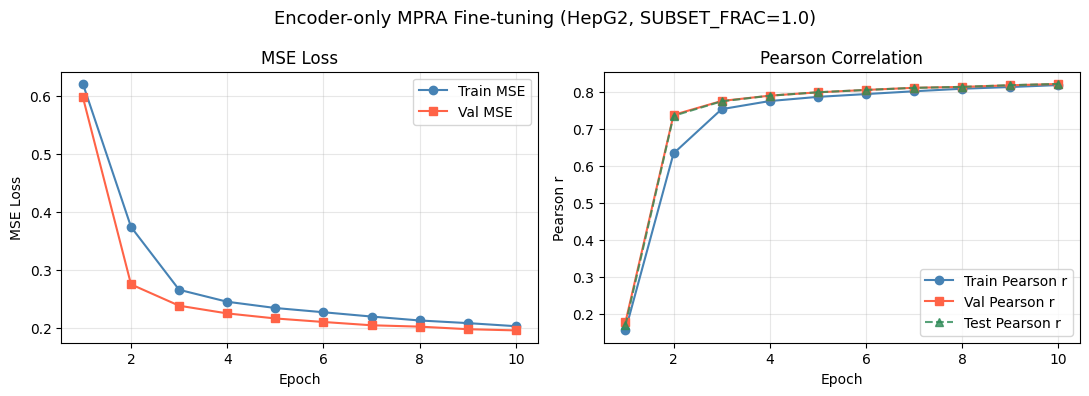

Plot saved to checkpoints_mpra/training_curves.png


In [14]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(history["train_loss"]) + 1))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle(f"Encoder-only MPRA Fine-tuning ({CELL_TYPE}, SUBSET_FRAC={SUBSET_FRAC})", fontsize=13)

# ── MSE loss ─────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs, history["train_loss"], marker="o", label="Train MSE", color="steelblue")
ax.plot(epochs, history["val_loss"],   marker="s", label="Val MSE",   color="tomato")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("MSE Loss")
ax.legend()
ax.grid(True, alpha=0.3)

# ── Pearson r ─────────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(epochs, history["train_pearson"], marker="o", label="Train Pearson r", color="steelblue")
ax.plot(epochs, history["val_pearson"],   marker="s", label="Val Pearson r",   color="tomato")
ax.plot(epochs, history["test_pearson"],  marker="^", label="Test Pearson r",  color="seagreen",
        linestyle="--", alpha=0.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("Pearson r")
ax.set_title("Pearson Correlation")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / "training_curves.png", dpi=150)
plt.show()

print(f"Plot saved to {CHECKPOINT_DIR / 'training_curves.png'}")

## 10. Final evaluation on the test set

Load the best checkpoint and evaluate on held-out fold 10.

In [15]:
# Load best checkpoint
ckpt = torch.load(CHECKPOINT_DIR / "best_head.pt", map_location=DEVICE, weights_only=True)
head.load_state_dict(ckpt["head"])
print(f"Loaded best checkpoint from epoch {ckpt['epoch']}")
print(f"  Checkpoint val MSE     : {ckpt['val_loss']:.6f}")
print(f"  Checkpoint val Pearson : {ckpt['val_pearson']:.4f}")

# Evaluate on test set (fold 10, held out during training)
test_loss, test_pearson = evaluate(
    model=model, head=head, loader=test_loader, device=DEVICE,
)
print()
print("=" * 50)
print(f"Test set (fold 10) results:")
print(f"  MSE     : {test_loss:.6f}")
print(f"  Pearson : {test_pearson:.4f}")
print("=" * 50)

Loaded best checkpoint from epoch 10
  Checkpoint val MSE     : 0.195261
  Checkpoint val Pearson : 0.8210

Test set (fold 10) results:
  MSE     : 0.198946
  Pearson : 0.8211


Test Pearson r  : 0.8211
Test Spearman r : 0.8038


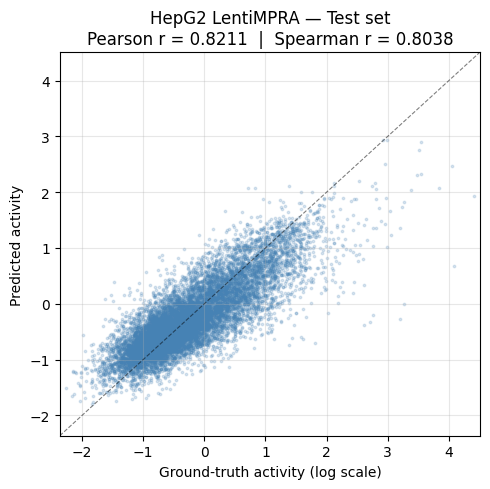

Scatter saved to checkpoints_mpra/test_scatter.png


In [16]:
# Scatter plot: predicted vs. ground-truth activity on the test set
import numpy as np
from scipy.stats import pearsonr, spearmanr

all_preds_test, all_tgts_test = [], []

model.eval()
head.eval()
with torch.no_grad():
    for sequences, targets in test_loader:
        sequences = sequences.to(DEVICE)
        organism_idx = torch.zeros(sequences.shape[0], dtype=torch.long, device=DEVICE)
        enc_out = model(sequences, organism_idx, encoder_only=True)["encoder_output"]
        preds = head(enc_out)
        all_preds_test.append(preds.float().cpu().numpy())
        all_tgts_test.append(targets.numpy())

preds_np = np.concatenate(all_preds_test)
tgts_np  = np.concatenate(all_tgts_test)

pearson_val,  _ = pearsonr(preds_np, tgts_np)
spearman_val, _ = spearmanr(preds_np, tgts_np)

print(f"Test Pearson r  : {pearson_val:.4f}")
print(f"Test Spearman r : {spearman_val:.4f}")

# Scatter plot
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(tgts_np, preds_np, alpha=0.2, s=3, color="steelblue", rasterized=True)
lims = [min(tgts_np.min(), preds_np.min()) - 0.1,
        max(tgts_np.max(), preds_np.max()) + 0.1]
ax.plot(lims, lims, "k--", linewidth=0.8, alpha=0.5)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Ground-truth activity (log scale)")
ax.set_ylabel("Predicted activity")
ax.set_title(
    f"{CELL_TYPE} LentiMPRA — Test set\n"
    f"Pearson r = {pearson_val:.4f}  |  Spearman r = {spearman_val:.4f}"
)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / "test_scatter.png", dpi=150)
plt.show()

print(f"Scatter saved to {CHECKPOINT_DIR / 'test_scatter.png'}")

## Summary

Finetuning the encoder achieves
**test Pearson r = 0.82+** on HepG2 LentiMPRA.

### What we did:
| Step | Description |
|------|-------------|
| `AlphaGenome()` + `load_trunk()` | Load pretrained backbone, exclude original heads |
| Freeze backbone | Zero trainable backbone parameters |
| `model(..., encoder_only=True)` | Run only the CNN encoder — skip transformer, decoder, embedders |
| `MPRAHead` | LayerNorm → flatten → Linear → ReLU → Dropout → Linear(→1) |
| MSE loss | Regression on log-scale MPRA activity scores |
| Pearson r | Evaluation metric per epoch |